## DATA200 Final Project



Imports

In [2]:
#imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, mean_absolute_error

In [3]:
#loading data sets
batting_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/Batting.csv"
players_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/People.csv"
fielding_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/Fielding.csv"
people_info = pd.read_csv(players_url)
batting_info = pd.read_csv(batting_url)
fielding_info = pd.read_csv(fielding_url)[['playerID', 'POS']]

In [4]:
#merging data sets
hitting_stats = pd.merge(batting_info, people_info, on='playerID', how='inner')
players_stats = pd.merge(fielding_info, hitting_stats, on='playerID', how='inner')
players_stats = players_stats[players_stats['POS'] != 'P']
print(players_stats.head())

     playerID POS  yearID  stint teamID lgID    G   AB    R    H  ...  \
81  aaronha01  OF    1954      1    ML1   NL  122  468   58  131  ...   
82  aaronha01  OF    1955      1    ML1   NL  153  602  105  189  ...   
83  aaronha01  OF    1956      1    ML1   NL  153  609  106  200  ...   
84  aaronha01  OF    1957      1    ML1   NL  151  615  118  198  ...   
85  aaronha01  OF    1958      1    ML1   NL  153  601  109  196  ...   

    nameLast    nameGiven  weight  height  bats  throws       debut  \
81     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
82     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
83     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
84     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
85     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   

      bbrefID   finalGame   retroID  
81  aaronha01  1976-10-03  aaroh101  
82  aaronha01  1976-10-03  aaroh101  
83  aaronha01  1976-

In [5]:
#adding the year each player debuted and how many years they have played so far
players_stats['debut_year'] = pd.to_datetime(players_stats['debut']).dt.year
players_stats = players_stats[players_stats['debut_year'] >= 2004]
players_stats['debut_year'] = players_stats['debut_year'].astype(int)

players_stats['years_in'] = players_stats['yearID'] - players_stats['debut_year']

In [6]:
#filtering to only include the first stint of each player in a season to avoid duplicates and minor league stats and ensure we are only looking at their primary team performance
players_stats = players_stats[players_stats['stint'] == 1]

In [7]:
#dropping irrelivant coloumns
columns_to_drop = ['POS', 'stint', 'teamID', 'lgID', 'birthMonth', 'birthDay',
                   'birthCity', 'birthCountry', 'birthState', 'deathYear', 'deathMonth',
                   'deathDay', 'deathCity', 'deathCountry', 'deathState', 'throws', 'debut', 'finalGame', 'bbrefID', 'retroID']
players_stats = players_stats.drop(columns=columns_to_drop)
print(players_stats.head())

       playerID  yearID    G   AB   R   H  2B  3B  HR   RBI  ...  ID  \
2448  abercre01    2006  111  255  39  54  12   2   5  24.0  ...  23   
2449  abercre01    2007   35   76  16  15   3   0   2   5.0  ...  23   
2450  abercre01    2008   34   55  10  17   5   0   2   5.0  ...  23   
2451  abercre01    2006  111  255  39  54  12   2   5  24.0  ...  23   
2452  abercre01    2007   35   76  16  15   3   0   2   5.0  ...  23   

      birthYear  nameFirst     nameLast          nameGiven  weight  height  \
2448     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2449     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2450     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2451     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   
2452     1980.0     Reggie  Abercrombie  Reginald Damascus   215.0    75.0   

      bats  debut_year  years_in  
2448     R        2006         0  
2449     R        2006      

In [8]:
#dropping duplicate rows
players_stats = players_stats.drop_duplicates()

In [9]:
#adding the stat singles and unintentional walks to then calculate wOBA
players_stats['1B'] = players_stats['H'] - (players_stats['2B'] + players_stats['3B'] + players_stats['HR'])

players_stats['uBB'] = players_stats['BB'] - players_stats['IBB']

players_stats['wOBA'] = (0.69*players_stats['uBB']+0.722*players_stats['HBP']+0.888*players_stats['1B']+1.271*players_stats['2B']+1.616*players_stats['3B']+2.101*players_stats['HR'])/(players_stats['AB']+players_stats['BB']-players_stats['IBB']+players_stats['SF']+players_stats['HBP'])

In [10]:
#setting a minimum AB and Games played per season to make sure we do not get any extreme outliers (very low but succsessful ABs)
MIN_AB = 100
MIN_G  = 30

players_stats = players_stats[(players_stats['AB'] >= MIN_AB) & (players_stats['G'] >= MIN_G)]

In [11]:
#comparing the wOBA to the previous year to determine if a player had a breakout season or not, and then calculating the percentage change in wOBA from the previous year to the current year.
players_stats = players_stats.sort_values(['playerID', 'yearID'])

players_stats['woba_prev_year'] = players_stats.groupby('playerID')['wOBA'].shift(1)

players_stats['woba_yoy_pct'] = ((players_stats['wOBA'] - players_stats['woba_prev_year']) / players_stats['woba_prev_year'])*100

BREAKOUT_THRESHOLD = players_stats[players_stats['yearID'] < 2024]['woba_yoy_pct'].quantile(0.75)

players_stats['breakout'] = (players_stats['woba_yoy_pct'] >= BREAKOUT_THRESHOLD).astype(int)

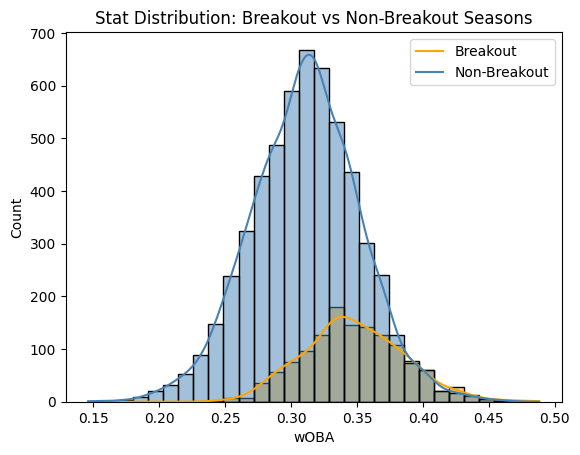

In [12]:
#histoplot showing the difference in breakout vs non breakout seasons. breakout seasons have a higher mean in wOBA
sns.histplot(data=players_stats, x='wOBA', hue='breakout',
             kde=True, bins=30, palette={0: 'steelblue', 1: 'orange'})

plt.title('Stat Distribution: Breakout vs Non-Breakout Seasons')
plt.xlabel('wOBA')
plt.ylabel('Count')
plt.legend(labels=['Breakout', 'Non-Breakout'])
plt.show()

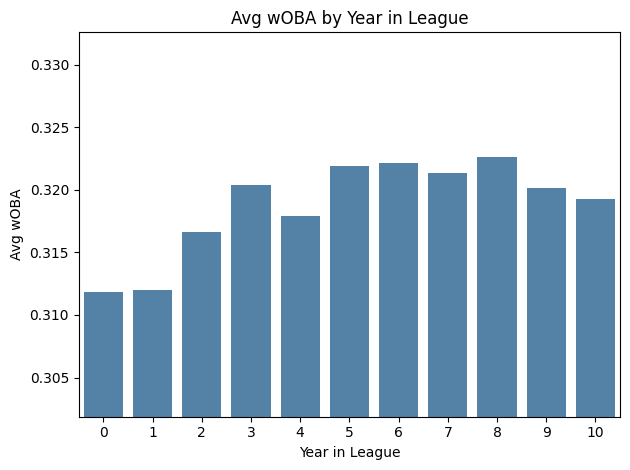

In [13]:
#barplot showing the avg wOBA by years in league, helps show where wOBA tends to increase and decrease
avg_players_stats = players_stats[players_stats['years_in'] <= 10].groupby('years_in')['wOBA'].mean().reset_index()

sns.barplot(data=avg_players_stats, x='years_in', y='wOBA', color='steelblue')

plt.title('Avg wOBA by Year in League')
plt.xlabel('Year in League')
plt.ylabel('Avg wOBA')

plt.ylim(avg_players_stats['wOBA'].min() - 0.01, avg_players_stats['wOBA'].max() + 0.01)

plt.tight_layout()
plt.show()

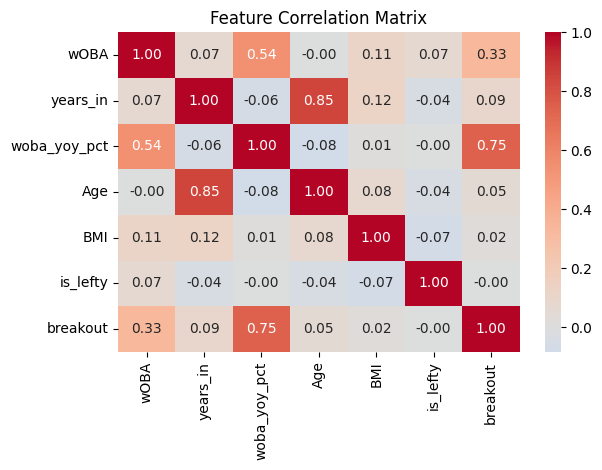

In [14]:
#heatmap to show the correlation between two stats/features
players_stats['Age'] = players_stats['yearID'] - players_stats['birthYear']
players_stats['BMI'] = (players_stats['weight'] / (players_stats['height']**2)) * 703
players_stats['is_lefty'] = (players_stats['bats'] == 'L').astype(int)

corr_cols = ['wOBA', 'years_in', 'woba_yoy_pct', 'Age', 'BMI', 'is_lefty', 'breakout']

corr = players_stats[corr_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [15]:
features = ['woba_prev_year', 'years_in', 'Age', 'BMI', 'is_lefty']

players_stats_clean = players_stats.dropna(subset = features + ['woba_yoy_pct', 'breakout'])

X = players_stats_clean[features]
y_regression = players_stats_clean['woba_yoy_pct']
y_classification = players_stats_clean['breakout']

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_regression, test_size = 0.20, random_state = 19)
X_train, X_test, y_train_cls, y_test_cls = train_test_split(X, y_classification, test_size = 0.20, random_state = 19)
#Add , random_state = 42 after test_size = 0.2 if you want fixed results and not different everytime

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv = 5).fit(X_train_scaled, y_train_reg)
print(f"Lasso R^2 Score: {lasso.score(X_test_scaled, y_test_reg):.4f}")

rf = RandomForestClassifier(n_estimators = 100, random_state = 19)
rf.fit(X_train, y_train_cls)
print("\nRandom Forest Report: ")
print(classification_report(y_test_cls, rf.predict(X_test)))

Lasso R^2 Score: 0.2832

Random Forest Report: 
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       809
           1       0.57      0.34      0.42       265

    accuracy                           0.77      1074
   macro avg       0.69      0.63      0.64      1074
weighted avg       0.75      0.77      0.75      1074



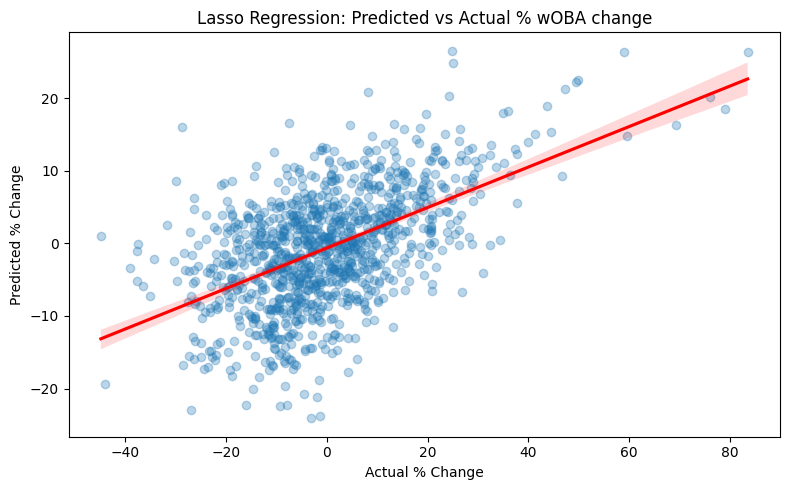

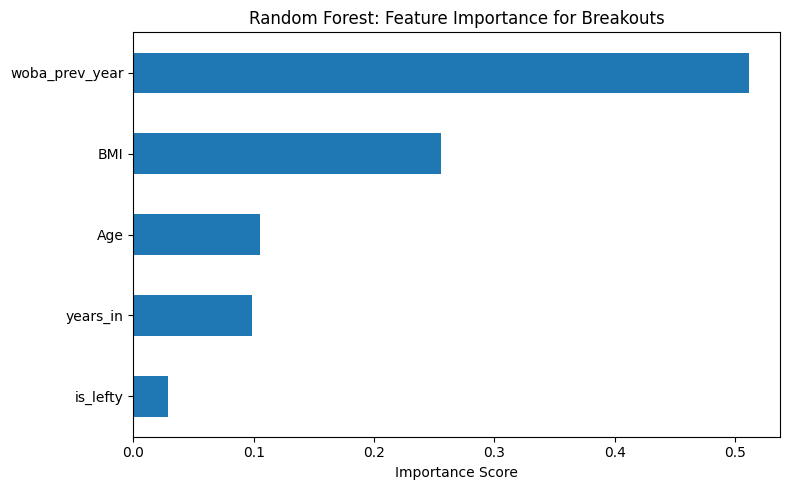

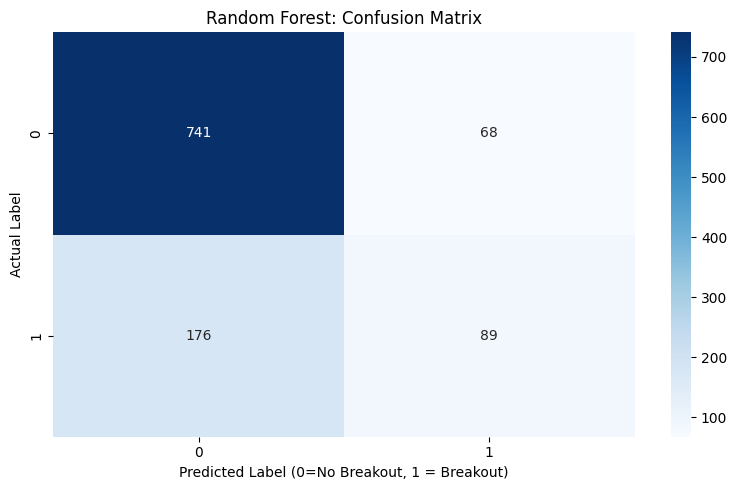

In [16]:
#Lasso Regression: Predictions vs Actual
y_pred_reg = lasso.predict(X_test_scaled)
plt.figure(figsize = (8,5))
sns.regplot(x = y_test_reg, y = y_pred_reg, scatter_kws = {'alpha': 0.3}, line_kws = {'color': 'red'})
plt.title('Lasso Regression: Predicted vs Actual % wOBA change')
plt.xlabel('Actual % Change')
plt.ylabel('Predicted % Change')
plt.tight_layout()
plt.show()

#Random Forest: Importance of Features
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize = (8,5))
importances.plot(kind = 'barh')
plt.title('Random Forest: Feature Importance for Breakouts')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#Confusion Matrix: Accuracy of Classification
cm = confusion_matrix(y_test_cls, rf.predict(X_test))
plt.figure(figsize = (8,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Random Forest: Confusion Matrix')
plt.xlabel('Predicted Label (0=No Breakout, 1 = Breakout)')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# Conclusion

### Evaluating Results
Looking at our lasso regression model, we notice a 0.2832 R-squared value. The R-squared value represents the percentage of our features that explain the variance of our data. This means that around 28.32% of the data can be explained by our features: age, previous performances, BMI, years in the league, and whether they are a lefty batter. In baseball specifically, it is notoriously hard to predict year-to-year changes solely based on previous data because players tend to make adjustments during the off-season that the model does not predict, so being able to predict around 28% of their final outcome is a great number.

Using our random forest model, we notice that the report gave us a 77% accuracy. This percentage indicates that the random forest model predicts whether a player will break out or not correctly around 8 out of 10 times, which is pretty good with all the variation in the game of baseball. Comparing accuracy to precision, we have that the model was accurate 77% of the time, but it was precise 57% of the time. Precision indicates that when the model says the player is going to break out, they break out 57% of the time. 

In our dataset, we can see that 265 of the 1074 eligible batters broke out according to the 75th percentile threshold as seen in the random forest model report. If we simply guessed that every player would not breakout, we would be correct around 75% of the time (accuracy). Our model has around a 77% accuracy rate, meaning the model is around 2% better than a blind guess. On the other hand, we can say that if we were to predict a breakout for every player, we would be correct around 25% of the time (precision). Our model has a 57% percentage rate, meaning that when our model predicts a breakout, it is more often correct compared to a blind guess by a huge 32%. 

### Relation to Goals

Goal 1: Predict the wOBA for a player the following season
- We can predict a player's wOBA the following season with the lasso regression model to an extent
- Using the lasso regression, it forces the model to only focus on the most stable predictors like age and previous wOBA, while taking the less stable predictors to around zero BMI or if they are a lefty
- The R-squared value of 0.2832 proves that we cannot predict a player's exact wOBA because of the randomness and streakiness of the sport
- We can predict around 30% of their development, which does not predict their wOBA exactly, but we can get a range on what it will be

Goal 2: Predict whether a player will have a breakout season
- We can use the random forest classifier to define what a breakout is and predict the probability of someone breaking out in the next season
- Baseball and humans are not a straight linear line in terms of progression; BMI, years in the league and wOBA in previous years change depending on so many factors
- The random forest is used to find non-linear patterns, which allows us to categorize players as breakouts that a simple linear regression might miss
- The 5-fold cross-validation proves that the model's ability to predict a breakout is not just a fluke

### What does this mean for 2025
- Lasso tells us the expected growth, and random forest tells us the probability of that growth being a true breakout
- With both of those in mind, the models were able to compile a list of the players with the highest breakout possibilities in 2025
- Below is the top 50 list of breakouts in 2025

In [17]:
data_2025 = players_stats[players_stats['yearID'] == 2025].dropna(subset = features).copy()
data_2025['breakout_prob'] = rf.predict_proba(data_2025[features])[:, 1]

top_candidates = data_2025.sort_values('breakout_prob', ascending = False).head(50)
print(top_candidates[['playerID', 'nameFirst', 'nameLast', 'Age', 'woba_prev_year', 'breakout_prob']])

          playerID  nameFirst    nameLast   Age  woba_prev_year  breakout_prob
1444470  scottvi01     Victor       Scott  24.0        0.222871           1.00
1578663  taylomi02    Michael      Taylor  34.0        0.244209           0.98
57745     baezja01     Javier        Baez  33.0        0.226764           0.96
377555   davishe01      Henry       Davis  26.0        0.214642           0.96
999422   marteno01     Noelvi       Marte  24.0        0.245037           0.96
742526   hollija01    Jackson    Holliday  22.0        0.253918           0.96
915704     leebr02     Brooks         Lee  24.0        0.254749           0.95
92237     beckjo01     Jordan        Beck  24.0        0.233142           0.95
1540272  storytr01     Trevor       Story  33.0        0.252583           0.93
715795   herrejo04       Jose     Herrera  28.0        0.256809           0.93
943394   loftini01       Nick      Loftin  27.0        0.243771           0.93
1014923  matoslu02       Luis       Matos  23.0     